In [ ]:
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

# Assuming my CSV file is in the 'data' folder within your Google Drive
file_path = '/content/drive/MyDrive/solar3/dataset.csv'

# Read the CSV file into a DataFrame
df = pd.read_csv(file_path)

# Display the first few rows of the DataFrame
df

,Absorber defect density,Series resistance,Shunt resistance,Reflection,Radiative recombination,Efficiency
0,1.000000e+12,1.0,10.0,0.05,1.000000e-06,1.43
1,1.000000e+12,1.0,10.0,0.05,1.000000e-07,1.95
2,1.000000e+12,1.0,10.0,0.05,1.000000e-10,2.07
3,1.000000e+12,1.0,10.0,0.05,1.000000e-11,2.07
4,1.000000e+12,1.0,10.0,0.15,1.000000e-06,1.15
...,...,...,...,...,...,...
1019,1.000000e+16,5.0,100000.0,0.20,1.000000e-11,11.50
1020,1.000000e+16,5.0,100000.0,0.25,1.000000e-06,5.97
1021,1.000000e+16,5.0,100000.0,0.25,1.000000e-07,9.69
1022,1.000000e+16,5.0,100000.0,0.25,1.000000e-10,10.80


In [ ]:
df.rename(columns=lambda x: x.strip(), inplace=True)
print(df.columns.tolist())


['Absorber defect density', 'Series resistance', 'Shunt resistance', 'Reflection', 'Radiative recombination', 'Efficiency']


# **RF feature importance technique**

Feature Importances:

                   Feature  Importance
2         Shunt resistance    0.703416
4  Radiative recombination    0.189300
0  Absorber defect density    0.068684
3               Reflection    0.030345
1        Series resistance    0.008255


/tmp/ipython-input-379005381.py:45: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(feature_importance_df["Feature"], fontweight='bold')  # Make bold


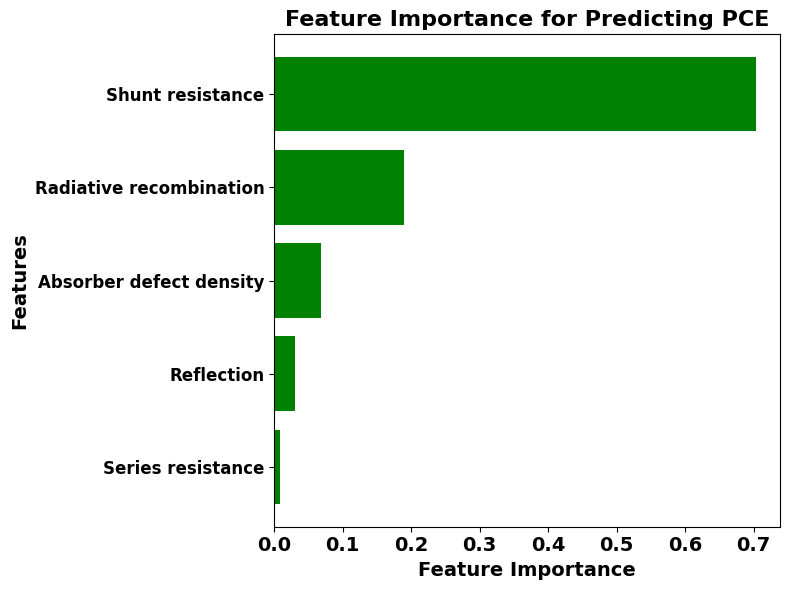


Feature importance plot saved at /content/drive/MyDrive/solar3/feature_importance.png


In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Clean column names by stripping trailing or leading spaces
df.columns = df.columns.str.strip()

# Separate features and target
X = df.drop(columns=["Efficiency"])
y = df["Efficiency"]

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a Random Forest model
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

# Get feature importances
importances = model.feature_importances_
feature_names = X.columns

# Create a DataFrame for visualization
feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

# Print the feature importance DataFrame
print("Feature Importances:\n")
print(feature_importance_df)

# Plot the feature importances
plt.figure(figsize=(8, 6))
plt.barh(feature_importance_df["Feature"], feature_importance_df["Importance"], color="green")
plt.xlabel("Feature Importance", fontsize=14, fontweight="bold")
plt.ylabel("Features", fontsize=14, fontweight="bold")
plt.title("Feature Importance for Predicting PCE", fontsize=16, fontweight="bold")
plt.gca().invert_yaxis()

# Make y-tick labels bold and larger
plt.tick_params(axis='y', labelsize=12)  # Increase font size
plt.xticks(fontsize=14, fontweight='bold')
plt.gca().set_yticklabels(feature_importance_df["Feature"], fontweight='bold')  # Make bold

# Save the plot as an image in 300 DPI
image_path = '/content/drive/MyDrive/solar3/feature_importance.png'
plt.savefig(image_path, dpi=300, bbox_inches="tight")
plt.tight_layout()
# Show the plot
plt.show()

print(f"\nFeature importance plot saved at {image_path}")


# **Correlation Analysis**

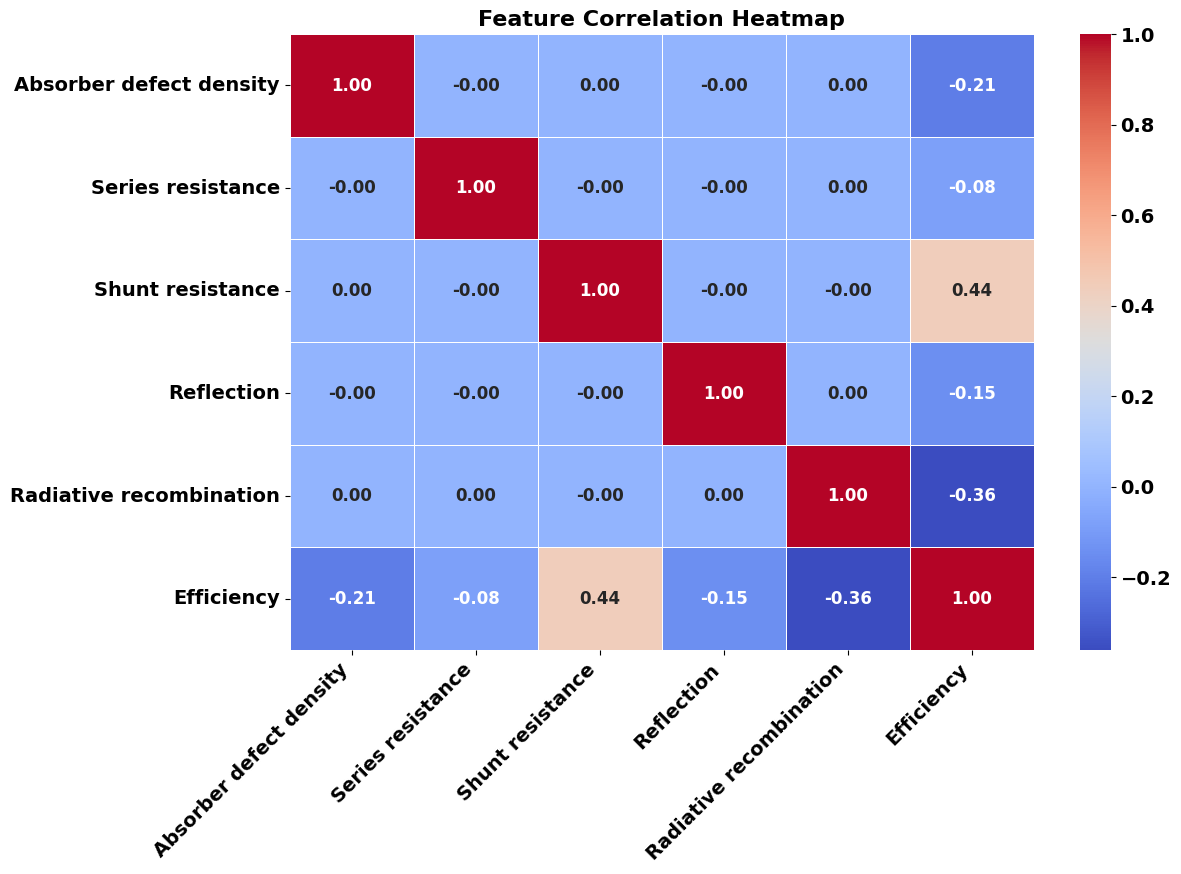

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Compute correlation matrix
corr_matrix = df.corr()

# Plot heatmap
plt.figure(figsize=(12, 8))
heatmap = sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5,
    annot_kws={"size": 12, "weight": "bold"}  # Increase size and boldness of internal values
)

# Set title
plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold')

# Set x and y axis labels font size and bold
plt.xticks(fontsize=14, fontweight='bold', rotation=45, ha='right')
plt.yticks(fontsize=14, fontweight='bold')

# Save the plot as an image in 300 DPI
image_path = '/content/drive/MyDrive/solar3/correlation.png'
plt.savefig(image_path, dpi=300, bbox_inches="tight")
plt.show()


# **Final RF**

Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Best CV R2 Score from GridSearch: 0.9988

--- 5-Fold Cross-Validation Results (Training Data) ---
Mean CV R2: 0.998831 (+/- 0.000315)
Mean CV RMSE: 0.212591

Final Test Final Metrics:
MSE: 0.024937
RMSE: 0.157915
MAE: 0.104765
R2 Score: 0.999373


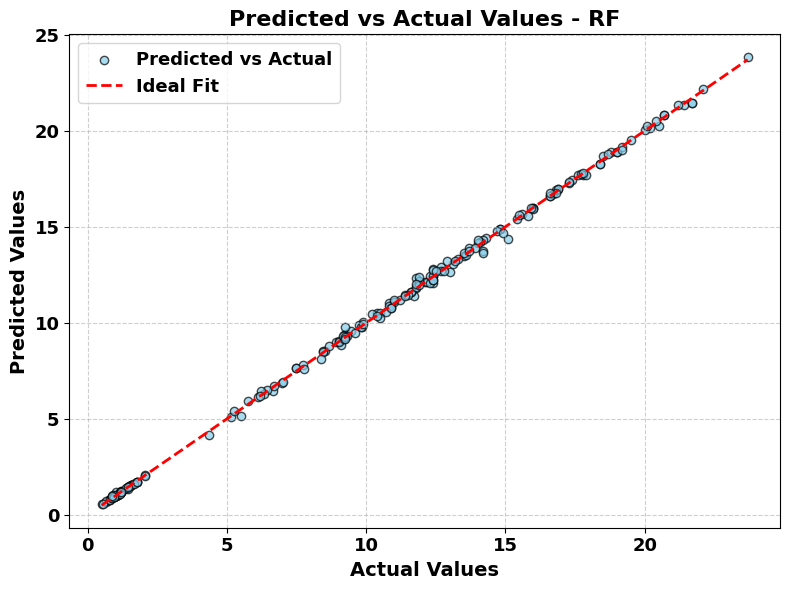

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, explained_variance_score
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load your dataset
# df = pd.read_csv("/content/drive/MyDrive/solar/solar3/your_dataset.csv")

# 2. Define features and target (Based on your 5-feature setup)
# Features: Absorber defect density, Series resistance, Shunt resistance, Reflection, Radiative recombination
X = df.drop(columns=["Efficiency"])
y = df["Efficiency"]

# 3. Split the dataset: 80% Training, 20% Testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Scale the data strictly fitting on Training set
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert to DataFrame
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns)

# 5. Grid Search CV for Hyperparameter Optimization
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5, 10]
}

rf = RandomForestRegressor(random_state=42)
# The 'cv=5' here performs internal cross-validation during the search
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, scoring='r2', n_jobs=-1)
grid_search.fit(X_train_scaled_df, y_train)

# 6. Best model and internal validation metrics
best_model = grid_search.best_estimator_
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best CV R2 Score from GridSearch: {grid_search.best_score_:.4f}")

# 7. MANUALLY CALCULATE 5-FOLD CV SCORE
# This evaluates the optimized model across 5 different folds of the training data
cv_r2_scores = cross_val_score(best_model, X_train_scaled_df, y_train, cv=5, scoring='r2')
cv_rmse_scores = cross_val_score(best_model, X_train_scaled_df, y_train, cv=5, scoring='neg_root_mean_squared_error')

print("\n--- 5-Fold Cross-Validation Results (Training Data) ---")
print(f"Mean CV R2: {cv_r2_scores.mean():.6f} (+/- {cv_r2_scores.std():.6f})")
print(f"Mean CV RMSE: {(-cv_rmse_scores.mean()):.6f}")

# 8. Predict on test set for Final Performance
y_test_pred = best_model.predict(X_test_scaled_df)

# Evaluation function
def evaluate_model(y_true, y_pred, dataset_name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    evs = explained_variance_score(y_true, y_pred)

    print(f"\n{dataset_name} Final Metrics:")
    print(f"MSE: {mse:.6f}")
    print(f"RMSE: {rmse:.6f}")
    print(f"MAE: {mae:.6f}")
    print(f"R2 Score: {r2:.6f}")
    return r2

# Final Test evaluation
final_r2 = evaluate_model(y_test, y_test_pred, "Final Test")


# 9. Plotting
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_test_pred, color='skyblue', edgecolor='black',
            alpha=0.7, label='Predicted vs Actual')

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', lw=2, label='Ideal Fit')

plt.title('Predicted vs Actual Values - RF', fontsize=16, fontweight='bold')
plt.xlabel('Actual Values', fontsize=14, fontweight='bold')
plt.ylabel('Predicted Values', fontsize=14, fontweight='bold')

# Axis numbers bold + larger
plt.xticks(fontsize=13, fontweight='bold')
plt.yticks(fontsize=13, fontweight='bold')

# 🔹 Legend bold
plt.legend(prop={'size': 13, 'weight': 'bold'})

plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

plt.savefig("/content/drive/MyDrive/solar3/Final_RF_Parity_Plot.png", dpi=300)
plt.show()

# **SVR**

Best Parameters: {'C': 100, 'epsilon': 0.5, 'kernel': 'rbf'}

--- 5-Fold Cross-Validation Results ---
Mean CV R2: 0.545655 (+/- 0.023470)
Mean CV RMSE: 4.236401

Final Test Final Metrics:
MSE: 19.555057
RMSE: 4.422110
MAE: 2.743062
R2 Score: 0.508459


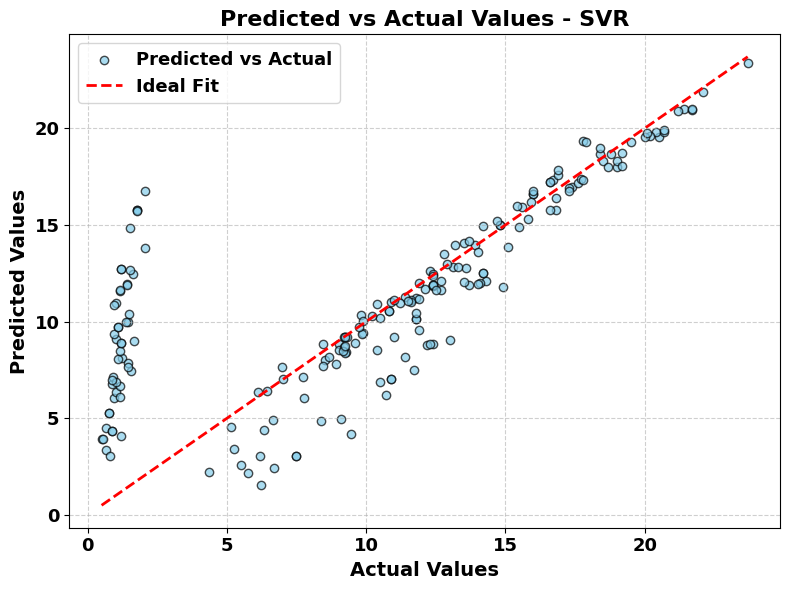

In [ ]:
import pandas as pd
import numpy as np
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, explained_variance_score
import matplotlib.pyplot as plt

# 1. Define features and target
# Based on the manuscript, inputs are the 5 experimental features
X = df.drop(columns=["Efficiency"])
y = df["Efficiency"]

# 2. Split the dataset (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Scale the data - Strictly fit on Training set to avoid leakage
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns)

# 4. Optimized Grid Search CV
param_grid = {
    "C": [0.1, 1, 10, 100],
    "epsilon": [0.01, 0.1, 0.5],
    "kernel": ["rbf"] # RBF is typically best for non-linear physical data
}

svr = SVR()
# cv=5 ensures internal validation during tuning
grid_search = GridSearchCV(estimator=svr, param_grid=param_grid, cv=5, scoring='r2', n_jobs=-1)
grid_search.fit(X_train_scaled_df, y_train)

best_model = grid_search.best_estimator_
print(f"Best Parameters: {grid_search.best_params_}")

# 5. GENERATE CROSS-VALIDATION SCORES
# This provides the Mean CV R2 and RMSE needed for Table 3 update
cv_r2_scores = cross_val_score(best_model, X_train_scaled_df, y_train, cv=5, scoring='r2')
cv_rmse_scores = cross_val_score(best_model, X_train_scaled_df, y_train, cv=5, scoring='neg_root_mean_squared_error')

print("\n--- 5-Fold Cross-Validation Results ---")
print(f"Mean CV R2: {cv_r2_scores.mean():.6f} (+/- {cv_r2_scores.std():.6f})")
print(f"Mean CV RMSE: {(-cv_rmse_scores.mean()):.6f}")

# 6. Final Evaluation on unseen Test Set
y_test_pred = best_model.predict(X_test_scaled_df)

def evaluate_model(y_true, y_pred, dataset_name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(f"\n{dataset_name} Final Metrics:")
    print(f"MSE: {mse:.6f}")
    print(f"RMSE: {rmse:.6f}")
    print(f"MAE: {mae:.6f}")
    print(f"R2 Score: {r2:.6f}")

evaluate_model(y_test, y_test_pred, "Final Test")

# 7. Plotting
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_test_pred, color='skyblue', edgecolor='black',
            alpha=0.7, label='Predicted vs Actual')

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', lw=2, label='Ideal Fit')

plt.title('Predicted vs Actual Values - SVR', fontsize=16, fontweight='bold')
plt.xlabel('Actual Values', fontsize=14, fontweight='bold')
plt.ylabel('Predicted Values', fontsize=14, fontweight='bold')

# Axis numbers bold + larger
plt.xticks(fontsize=13, fontweight='bold')
plt.yticks(fontsize=13, fontweight='bold')

# 🔹 Legend bold
plt.legend(prop={'size': 13, 'weight': 'bold'})

plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

plt.savefig("/content/drive/MyDrive/solar3/Final_SVR_Parity_Plot.png", dpi=300)
plt.show()

# **GBR**

Best Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 300}

--- 5-Fold Cross-Validation Results (Training Set) ---
Mean CV R2: 0.999789 (+/- 0.000078)
Mean CV RMSE: 0.089397

Final Test Final Metrics (Unseen Data):
MSE: 0.004866
RMSE: 0.069760
MAE: 0.048940
R2 Score: 0.999878
Explained Variance: 0.999881


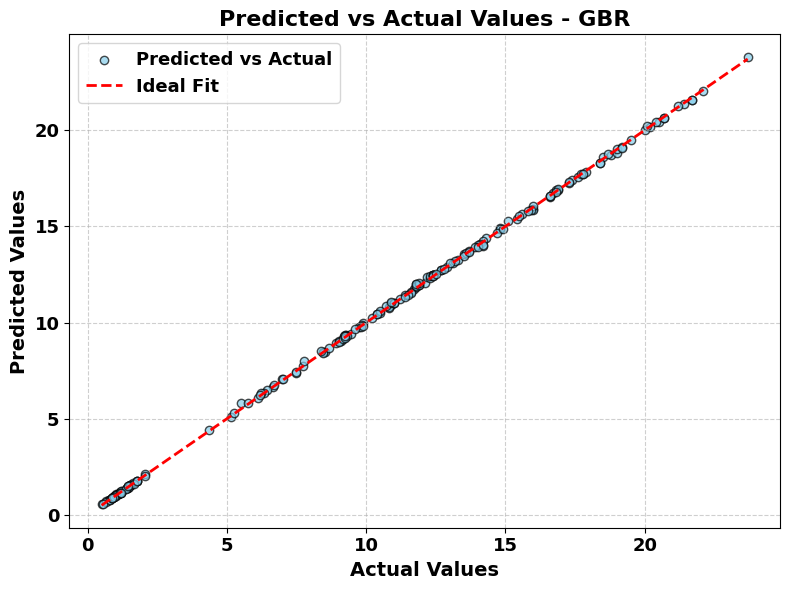

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, explained_variance_score
import matplotlib.pyplot as plt

# 1. Define features and target (Inputs: the 5 non-ideal features)
X = df.drop(columns=["Efficiency"])
y = df["Efficiency"]

# 2. Split the dataset (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Scale the data - Strictly fit ONLY on Training set
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert to DataFrame for easier handling
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns)

# 4. Grid Search CV for Hyperparameter Tuning
param_grid = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.01, 0.1, 0.2],
    "max_depth": [3, 5, 7]
}

gbr = GradientBoostingRegressor(random_state=42)
# Performs internal CV to select the best hyperparameter combination
grid_search = GridSearchCV(estimator=gbr, param_grid=param_grid, cv=5, scoring='r2', n_jobs=-1)
grid_search.fit(X_train_scaled_df, y_train)

# 5. Extract Best Model
best_model = grid_search.best_estimator_
print(f"Best Parameters: {grid_search.best_params_}")

# 6. CALCULATE EXPLICIT 5-FOLD CV SCORES (Crucial for Reviewer Response)
# This validates the best model's stability across the training data
cv_r2_scores = cross_val_score(best_model, X_train_scaled_df, y_train, cv=5, scoring='r2')
cv_rmse_scores = cross_val_score(best_model, X_train_scaled_df, y_train, cv=5, scoring='neg_root_mean_squared_error')

print("\n--- 5-Fold Cross-Validation Results (Training Set) ---")
print(f"Mean CV R2: {cv_r2_scores.mean():.6f} (+/- {cv_r2_scores.std():.6f})")
print(f"Mean CV RMSE: {(-cv_rmse_scores.mean()):.6f}")

# 7. Final Prediction and Evaluation on unseen Test Set
y_test_pred = best_model.predict(X_test_scaled_df)

def evaluate_model(y_true, y_pred, dataset_name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    evs = explained_variance_score(y_true, y_pred)

    print(f"\n{dataset_name} Final Metrics (Unseen Data):")
    print(f"MSE: {mse:.6f}")
    print(f"RMSE: {rmse:.6f}")
    print(f"MAE: {mae:.6f}")
    print(f"R2 Score: {r2:.6f}")
    print(f"Explained Variance: {evs:.6f}")

evaluate_model(y_test, y_test_pred, "Final Test")

# 8. Parity Plot for Manuscript
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_test_pred, color='skyblue', edgecolor='black',
            alpha=0.7, label='Predicted vs Actual')

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', lw=2, label='Ideal Fit')

plt.title('Predicted vs Actual Values - GBR', fontsize=16, fontweight='bold')
plt.xlabel('Actual Values', fontsize=14, fontweight='bold')
plt.ylabel('Predicted Values', fontsize=14, fontweight='bold')

# Axis numbers bold + larger
plt.xticks(fontsize=13, fontweight='bold')
plt.yticks(fontsize=13, fontweight='bold')

# 🔹 Legend bold
plt.legend(prop={'size': 13, 'weight': 'bold'})

plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

plt.savefig("/content/drive/MyDrive/solar3/Final_GBR_Parity_Plot.png", dpi=300)
plt.show()

# **XGBoost Regressor**

Best Parameters: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 300, 'subsample': 0.8}

--- 5-Fold Cross-Validation Results (Training Set) ---
Mean CV R2: 0.999833 (+/- 0.000070)
Mean CV RMSE: 0.079387

Final Test Final Evaluation Metrics:
MSE: 0.003500
RMSE: 0.059162
MAE: 0.043080
R2 Score: 0.999912
Explained Variance: 0.999913


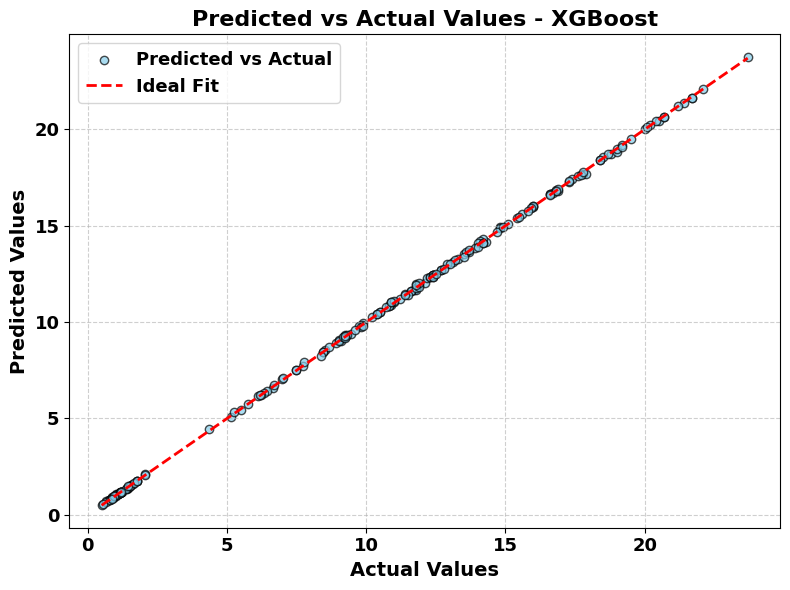

In [ ]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, explained_variance_score
import matplotlib.pyplot as plt

# 1. Load your dataset
# df = pd.read_csv("your_dataset.csv")

# 2. Define features and target (The 5 experimental input features)
X = df.drop(columns=["Efficiency"])
y = df["Efficiency"]

# 3. Split the dataset (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Scale the data - Strictly fit ONLY on Training set to prevent leakage
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert to DataFrame
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns)

# 5. Grid Search CV for Hyperparameter Optimization
param_grid = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.05, 0.1, 0.2],
    "max_depth": [3, 6, 9],
    "subsample": [0.8, 1.0]
}

xgb = XGBRegressor(random_state=42, verbosity=0)
# cv=5 performs internal cross-validation during the search process
grid_search = GridSearchCV(estimator=xgb, param_grid=param_grid, cv=5, scoring='r2', n_jobs=-1)
grid_search.fit(X_train_scaled_df, y_train)

# 6. Extract the Optimized Best Model
best_model = grid_search.best_estimator_
print(f"Best Parameters: {grid_search.best_params_}")

# 7. GENERATE CROSS-VALIDATION SCORES (The Reviewer's Key Requirement)
# This validates the model's stability across 5 different subsets of the training data
cv_r2_scores = cross_val_score(best_model, X_train_scaled_df, y_train, cv=5, scoring='r2')
cv_rmse_scores = cross_val_score(best_model, X_train_scaled_df, y_train, cv=5, scoring='neg_root_mean_squared_error')

print("\n--- 5-Fold Cross-Validation Results (Training Set) ---")
print(f"Mean CV R2: {cv_r2_scores.mean():.6f} (+/- {cv_r2_scores.std():.6f})")
print(f"Mean CV RMSE: {(-cv_rmse_scores.mean()):.6f}")

# 8. Final Prediction and Evaluation on unseen Test Set
y_test_pred = best_model.predict(X_test_scaled_df)

def evaluate_model(y_true, y_pred, dataset_name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    evs = explained_variance_score(y_true, y_pred)

    print(f"\n{dataset_name} Final Evaluation Metrics:")
    print(f"MSE: {mse:.6f}")
    print(f"RMSE: {rmse:.6f}")
    print(f"MAE: {mae:.6f}")
    print(f"R2 Score: {r2:.6f}")
    print(f"Explained Variance: {evs:.6f}")

evaluate_model(y_test, y_test_pred, "Final Test")

# 9. Final Parity Plot for the Manuscript
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_test_pred, color='skyblue', edgecolor='black',
            alpha=0.7, label='Predicted vs Actual')

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', lw=2, label='Ideal Fit')

plt.title('Predicted vs Actual Values - XGBoost', fontsize=16, fontweight='bold')
plt.xlabel('Actual Values', fontsize=14, fontweight='bold')
plt.ylabel('Predicted Values', fontsize=14, fontweight='bold')

# Axis numbers bold + larger
plt.xticks(fontsize=13, fontweight='bold')
plt.yticks(fontsize=13, fontweight='bold')

# 🔹 Legend bold
plt.legend(prop={'size': 13, 'weight': 'bold'})

plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

plt.savefig("/content/drive/MyDrive/solar3/Final_XGB_Parity_Plot.png", dpi=300)
plt.show()

# **MLPR**

Best Parameters: {'activation': 'relu', 'alpha': 0.0001, 'hidden_layer_sizes': (100,), 'learning_rate': 'constant', 'solver': 'adam'}

--- 5-Fold Cross-Validation Results (Training Data) ---
Mean CV R2: 0.678937 (+/- 0.011997)
Mean CV RMSE: 3.558855

Final Test Set Final Evaluation Metrics:
MSE: 13.072307
RMSE: 3.615565
MAE: 2.782770
R2 Score: 0.671411
Explained Variance: 0.672275


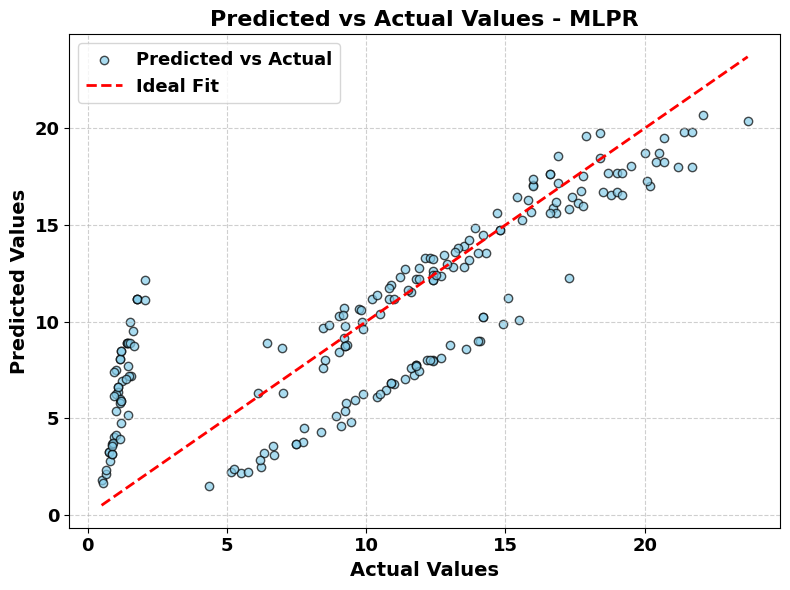

In [ ]:
import pandas as pd
import numpy as np
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, explained_variance_score
import matplotlib.pyplot as plt

# 1. Define features and target (Inputs: the 5 non-ideal features)
X = df.drop(columns=["Efficiency"])
y = df["Efficiency"]

# 2. Split the dataset: 80% Training, 20% Testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Scale the data - Strictly fitting only on the Training set to prevent leakage
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert scaled arrays back to DataFrame for consistency
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns)

# 4. Grid Search CV for Hyperparameter Optimization
param_grid = {
    "hidden_layer_sizes": [(100,), (100, 50), (150, 100, 50)],
    "activation": ["relu", "tanh"],
    "solver": ["adam"],
    "alpha": [0.0001, 0.001],
    "learning_rate": ["constant", "adaptive"]
}

mlp = MLPRegressor(max_iter=1000, random_state=42)
# Internal cv=5 during search process
grid_search = GridSearchCV(estimator=mlp, param_grid=param_grid, cv=5, scoring='r2', n_jobs=-1)
grid_search.fit(X_train_scaled_df, y_train)

# 5. Extract the optimized Best Model
best_model = grid_search.best_estimator_
print(f"Best Parameters: {grid_search.best_params_}")

# 6. MANUALLY CALCULATE 5-FOLD CV SCORES (Reviewer's Requirement)
# This validates the optimized model's stability across 5 different subsets of the data
cv_r2_scores = cross_val_score(best_model, X_train_scaled_df, y_train, cv=5, scoring='r2')
cv_rmse_scores = cross_val_score(best_model, X_train_scaled_df, y_train, cv=5, scoring='neg_root_mean_squared_error')

print("\n--- 5-Fold Cross-Validation Results (Training Data) ---")
print(f"Mean CV R2: {cv_r2_scores.mean():.6f} (+/- {cv_r2_scores.std():.6f})")
print(f"Mean CV RMSE: {(-cv_rmse_scores.mean()):.6f}")

# 7. Final Prediction and Evaluation on Unseen Test Data
y_test_pred = best_model.predict(X_test_scaled_df)

def evaluate_model(y_true, y_pred, dataset_name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    evs = explained_variance_score(y_true, y_pred)

    print(f"\n{dataset_name} Final Evaluation Metrics:")
    print(f"MSE: {mse:.6f}")
    print(f"RMSE: {rmse:.6f}")
    print(f"MAE: {mae:.6f}")
    print(f"R2 Score: {r2:.6f}")
    print(f"Explained Variance: {evs:.6f}")

evaluate_model(y_test, y_test_pred, "Final Test Set")

# 8. Parity Plot for Manuscript
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_test_pred, color='skyblue', edgecolor='black',
            alpha=0.7, label='Predicted vs Actual')

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', lw=2, label='Ideal Fit')

plt.title('Predicted vs Actual Values - MLPR', fontsize=16, fontweight='bold')
plt.xlabel('Actual Values', fontsize=14, fontweight='bold')
plt.ylabel('Predicted Values', fontsize=14, fontweight='bold')

# Axis numbers bold + larger
plt.xticks(fontsize=13, fontweight='bold')
plt.yticks(fontsize=13, fontweight='bold')

# 🔹 Legend bold
plt.legend(prop={'size': 13, 'weight': 'bold'})

plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

plt.savefig("/content/drive/MyDrive/solar3/Final_MLP_Parity_Plot.png", dpi=300)
plt.show()

# **LightGBM Regressor**

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000115 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 25
[LightGBM] [Info] Number of data points in the train set: 819, number of used features: 5
[LightGBM] [Info] Start training from score 9.834756
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

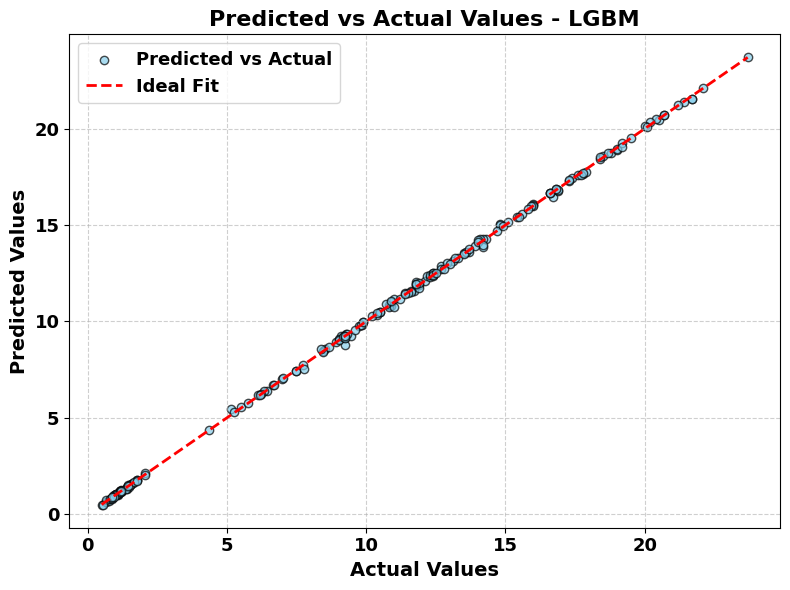

In [ ]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, explained_variance_score
import matplotlib.pyplot as plt

# 1. Define features and target (The 5 experimental input features)
X = df.drop(columns=["Efficiency"])
y = df["Efficiency"]

# 2. Split the dataset (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Scale the data - Strictly fit ONLY on Training set to prevent leakage
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert to DataFrame
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns)

# 4. Grid Search CV for Hyperparameter Optimization
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [-1, 10, 20],
    "learning_rate": [0.01, 0.1, 0.2],
    "num_leaves": [31, 50, 70]
}

lgbm = lgb.LGBMRegressor(random_state=42)
# Internal cv=5 during search process
grid_search = GridSearchCV(estimator=lgbm, param_grid=param_grid, cv=5, scoring='r2', n_jobs=-1)
grid_search.fit(X_train_scaled_df, y_train)

# 5. Extract the Optimized Best Model
best_model = grid_search.best_estimator_
print(f"Best Parameters: {grid_search.best_params_}")

# 6. MANUALLY CALCULATE 5-FOLD CV SCORE (The Reviewer's Key Requirement)
# This validates the optimized model across 5 different folds of the training data
cv_r2_scores = cross_val_score(best_model, X_train_scaled_df, y_train, cv=5, scoring='r2')
cv_rmse_scores = cross_val_score(best_model, X_train_scaled_df, y_train, cv=5, scoring='neg_root_mean_squared_error')

print("\n--- 5-Fold Cross-Validation Results (Training Data) ---")
print(f"Mean CV R2: {cv_r2_scores.mean():.6f} (+/- {cv_r2_scores.std():.6f})")
print(f"Mean CV RMSE: {(-cv_rmse_scores.mean()):.6f}")

# 7. Final Prediction and Evaluation on Unseen Test Set
y_test_pred = best_model.predict(X_test_scaled_df)

def evaluate_model(y_true, y_pred, dataset_name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    evs = explained_variance_score(y_true, y_pred)

    print(f"\n{dataset_name} Final Evaluation Metrics:")
    print(f"MSE: {mse:.6f}")
    print(f"RMSE: {rmse:.6f}")
    print(f"MAE: {mae:.6f}")
    print(f"R2 Score: {r2:.6f}")
    print(f"Explained Variance: {evs:.6f}")

evaluate_model(y_test, y_test_pred, "Final Test")

# 8. Parity Plot for Manuscript
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_test_pred, color='skyblue', edgecolor='black',
            alpha=0.7, label='Predicted vs Actual')

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', lw=2, label='Ideal Fit')

plt.title('Predicted vs Actual Values - LGBM', fontsize=16, fontweight='bold')
plt.xlabel('Actual Values', fontsize=14, fontweight='bold')
plt.ylabel('Predicted Values', fontsize=14, fontweight='bold')

# Axis numbers bold + larger
plt.xticks(fontsize=13, fontweight='bold')
plt.yticks(fontsize=13, fontweight='bold')

# 🔹 Legend bold
plt.legend(prop={'size': 13, 'weight': 'bold'})

plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

plt.savefig("/content/drive/MyDrive/solar3/Final_LGBM_Parity_Plot.png", dpi=300)
plt.show()

# **CatBoost Regressor**

Best Parameters: {'depth': 6, 'iterations': 300, 'learning_rate': 0.1}

--- 5-Fold Cross-Validation Results (Training Data) ---
Mean CV R2: 0.999672 (+/- 0.000194)
Mean CV RMSE: 0.108675

Final Test Set Final Evaluation Metrics:
MSE: 0.002756
RMSE: 0.052494
MAE: 0.034453
R2 Score: 0.999931
Explained Variance: 0.999933


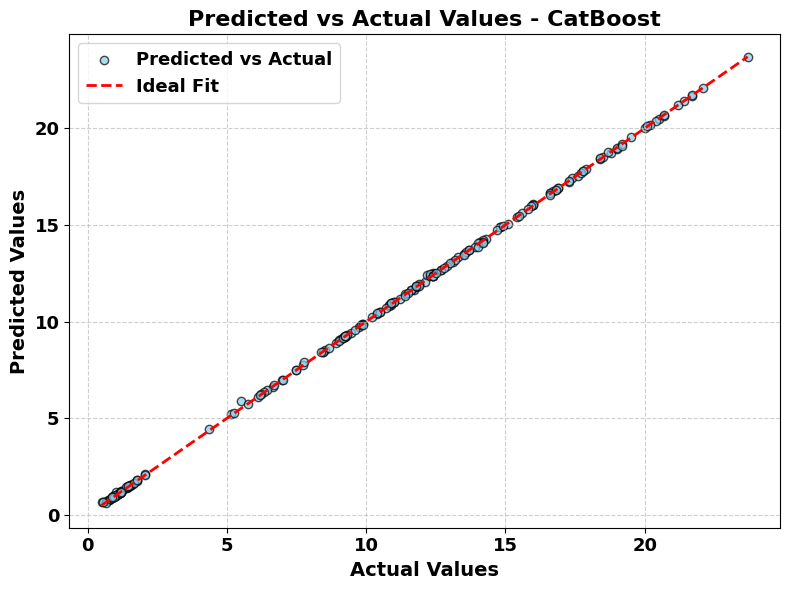

In [ ]:
import pandas as pd
import numpy as np
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, explained_variance_score
import matplotlib.pyplot as plt

# 1. Define features and target (Inputs: the 5 experimental input features)
# Based on the study's five key features [cite: 108]
X = df.drop(columns=["Efficiency"])
y = df["Efficiency"]

# 2. Split the dataset: 80% Training, 20% Testing [cite: 132]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Scale the data - Strictly fitting only on the Training set to prevent leakage [cite: 136]
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert scaled arrays back to DataFrame for consistency
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns)

# 4. Grid Search CV for Hyperparameter Optimization [cite: 140]
param_grid = {
    "iterations": [100, 200, 300],
    "depth": [6, 8, 10],
    "learning_rate": [0.01, 0.05, 0.1]
}

catboost = CatBoostRegressor(random_state=42, verbose=0)
# Internal cv=5 during the search process to ensure generalizability
grid_search = GridSearchCV(estimator=catboost, param_grid=param_grid, cv=5, scoring='r2', n_jobs=-1)
grid_search.fit(X_train_scaled_df, y_train)

# 5. Extract the optimized Best Model
best_model = grid_search.best_estimator_
print(f"Best Parameters: {grid_search.best_params_}")

# 6. MANUALLY CALCULATE 5-FOLD CV SCORE (The Reviewer's Key Requirement)
# This validates the optimized model's stability across 5 different subsets of the data
cv_r2_scores = cross_val_score(best_model, X_train_scaled_df, y_train, cv=5, scoring='r2')
cv_rmse_scores = cross_val_score(best_model, X_train_scaled_df, y_train, cv=5, scoring='neg_root_mean_squared_error')

print("\n--- 5-Fold Cross-Validation Results (Training Data) ---")
print(f"Mean CV R2: {cv_r2_scores.mean():.6f} (+/- {cv_r2_scores.std():.6f})")
print(f"Mean CV RMSE: {(-cv_rmse_scores.mean()):.6f}")

# 7. Final Prediction and Evaluation on Unseen Test Data
y_test_pred = best_model.predict(X_test_scaled_df)

def evaluate_model(y_true, y_pred, dataset_name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    evs = explained_variance_score(y_true, y_pred)

    print(f"\n{dataset_name} Final Evaluation Metrics:")
    print(f"MSE: {mse:.6f}")
    print(f"RMSE: {rmse:.6f}")
    print(f"MAE: {mae:.6f}")
    print(f"R2 Score: {r2:.6f}")
    print(f"Explained Variance: {evs:.6f}")

evaluate_model(y_test, y_test_pred, "Final Test Set")

# 8. Parity Plot for Manuscript
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_test_pred, color='skyblue', edgecolor='black',
            alpha=0.7, label='Predicted vs Actual')

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', lw=2, label='Ideal Fit')

plt.title('Predicted vs Actual Values - CatBoost', fontsize=16, fontweight='bold')
plt.xlabel('Actual Values', fontsize=14, fontweight='bold')
plt.ylabel('Predicted Values', fontsize=14, fontweight='bold')

# Axis numbers bold + larger
plt.xticks(fontsize=13, fontweight='bold')
plt.yticks(fontsize=13, fontweight='bold')

# 🔹 Legend bold
plt.legend(prop={'size': 13, 'weight': 'bold'})

plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

plt.savefig("/content/drive/MyDrive/solar3/Final_CatBoost_Parity_Plot.png", dpi=300)
plt.show()

In [ ]:
pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.7 MB/s eta 0:00:00


In [ ]:
pip install keras-tuner


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 5.5 MB/s eta 0:00:00


# **Deep Neural Network**

--- Best Hyperparameters Found ---
Layers: 3, Activation: tanh, LR: 0.01

--- Starting 5-Fold Cross-Validation (Training Set) ---
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
Fold 1 | R2: 0.6567 | RMSE: 3.5186
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
Fold 2 | R2: 0.6774 | RMSE: 3.4903
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
Fold 3 | R2: 0.6812 | RMSE: 3.7288
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
Fold 4 | R2: 0.7274 | RMSE: 3.4507
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
Fold 5 | R2: 0.6850 | RMSE: 3.3984

--- Mean Cross-Validation Results ---
Mean CV R2: 0.685550 (+/- 0.023093)
Mean CV MSE: 12.384733
Mean CV RMSE: 3.517375
Mean CV MAE: 2.722598
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step

--- Final Test Metrics (Unseen Data) ---
Mean Squared Error (MSE): 12.375595
Root Mean Squared Error (RMSE): 3.517896
Mean Absolute Error (MAE): 2.687533
R2 Score: 0.688924
Explained Variance Score: 0.689146


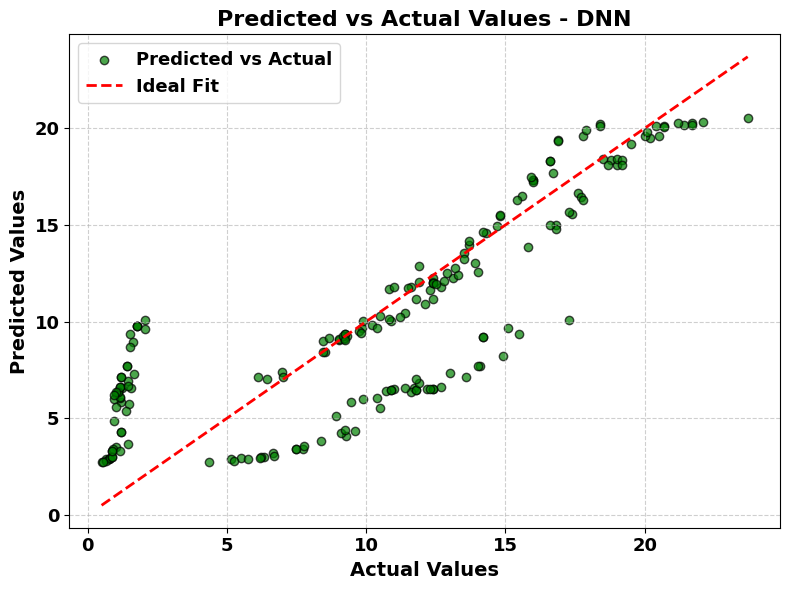

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
import keras_tuner as kt
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, explained_variance_score
import matplotlib.pyplot as plt

# 1. Define features and target (Inputs: the 5 experimental input features)
X = df.drop(columns=["Efficiency"])
y = df["Efficiency"]

# 2. Split the dataset (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Scale the data - Strictly fit ONLY on Training set to prevent data leakage
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Model Building Function for Keras Tuner
def build_model(hp):
    model = keras.Sequential()
    model.add(layers.Input(shape=(X_train_scaled.shape[1],)))

    # Tune number of hidden layers and units
    for i in range(hp.Int("num_layers", 1, 3)):
        model.add(layers.Dense(
            units=hp.Int(f"units_{i}", min_value=32, max_value=256, step=32),
            activation=hp.Choice("activation", ["relu", "tanh"])
        ))

    model.add(layers.Dense(1)) # Output layer for regression
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=hp.Choice("learning_rate", [1e-2, 1e-3, 1e-4])),
        loss="mse",
        metrics=["mae"]
    )
    return model

# 5. Initialize and Run Hyperparameter Tuner
tuner = kt.RandomSearch(
    build_model, objective="val_loss", max_trials=10, overwrite=True,
    directory="tuner_dir", project_name="solar_dnn_validated"
)

early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
tuner.search(X_train_scaled, y_train, validation_split=0.2, epochs=100, callbacks=[early_stop], verbose=0)

# Get the best hyperparameters
best_hps = tuner.get_best_hyperparameters(1)[0]
print(f"--- Best Hyperparameters Found ---")
print(f"Layers: {best_hps.get('num_layers')}, Activation: {best_hps.get('activation')}, LR: {best_hps.get('learning_rate')}")

# 6. PERFORM 5-FOLD CROSS-VALIDATION (The Reviewer's Key Requirement)

print("\n--- Starting 5-Fold Cross-Validation (Training Set) ---")
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Lists to store metrics for each fold
cv_r2, cv_mse, cv_rmse, cv_mae = [], [], [], []

for fold, (train_idx, val_idx) in enumerate(kf.split(X_train_scaled, y_train)):
    # Build fresh instance of the optimized architecture
    model = build_model(best_hps)

    # Train on the fold split
    model.fit(X_train_scaled[train_idx], y_train.iloc[train_idx],
              epochs=100, batch_size=32, verbose=0, callbacks=[early_stop],
              validation_data=(X_train_scaled[val_idx], y_train.iloc[val_idx]))

    # Predict on validation fold
    preds = model.predict(X_train_scaled[val_idx]).flatten()

    # Calculate metrics
    cv_r2.append(r2_score(y_train.iloc[val_idx], preds))
    cv_mse.append(mean_squared_error(y_train.iloc[val_idx], preds))
    cv_rmse.append(np.sqrt(cv_mse[-1]))
    cv_mae.append(mean_absolute_error(y_train.iloc[val_idx], preds))

    print(f"Fold {fold+1} | R2: {cv_r2[-1]:.4f} | RMSE: {cv_rmse[-1]:.4f}")

print("\n--- Mean Cross-Validation Results ---")
print(f"Mean CV R2: {np.mean(cv_r2):.6f} (+/- {np.std(cv_r2):.6f})")
print(f"Mean CV MSE: {np.mean(cv_mse):.6f}")
print(f"Mean CV RMSE: {np.mean(cv_rmse):.6f}")
print(f"Mean CV MAE: {np.mean(cv_mae):.6f}")

# 7. Final Evaluation on Unseen Test Set
final_model = tuner.get_best_models(num_models=1)[0]
y_test_pred = final_model.predict(X_test_scaled).flatten()

print("\n--- Final Test Metrics (Unseen Data) ---")
mse_test = mean_squared_error(y_test, y_test_pred)
print(f"Mean Squared Error (MSE): {mse_test:.6f}")
print(f"Root Mean Squared Error (RMSE): {np.sqrt(mse_test):.6f}")
print(f"Mean Absolute Error (MAE): {mean_absolute_error(y_test, y_test_pred):.6f}")
print(f"R2 Score: {r2_score(y_test, y_test_pred):.6f}")
print(f"Explained Variance Score: {explained_variance_score(y_test, y_test_pred):.6f}")

# 8. Parity Plot for Manuscript
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_test_pred, color='green', edgecolor='black',
            alpha=0.7, label='Predicted vs Actual')

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', lw=2, label='Ideal Fit')

plt.title('Predicted vs Actual Values - DNN', fontsize=16, fontweight='bold')
plt.xlabel('Actual Values', fontsize=14, fontweight='bold')
plt.ylabel('Predicted Values', fontsize=14, fontweight='bold')

# Axis numbers bold + larger
plt.xticks(fontsize=13, fontweight='bold')
plt.yticks(fontsize=13, fontweight='bold')

# 🔹 Legend bold
plt.legend(prop={'size': 13, 'weight': 'bold'})

plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

plt.savefig("/content/drive/MyDrive/solar3/Final_DNN_Parity_Plot.png", dpi=300)
plt.show()

# **CNN Regressor**

Reloading Tuner from cnn_cv_dir/untitled_project/tuner0.json
--- Best Hyperparameters Found ---
{'filters1': 96, 'kernel_size1': 2, 'filters2': 32, 'kernel_size2': 2, 'dense_units': 64, 'learning_rate': 0.01}

--- Starting 5-Fold Cross-Validation (Training Set) ---
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
Fold 1 | R2: 0.6576 | RMSE: 3.5141
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
Fold 2 | R2: 0.6724 | RMSE: 3.5176
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
Fold 3 | R2: 0.6800 | RMSE: 3.7361
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
Fold 4 | R2: 0.7498 | RMSE: 3.3060
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
Fold 5 | R2: 0.7071 | RMSE: 3.2767

--- Mean Cross-Validation Results ---
Mean CV R2: 0.693375 (+/- 0.032464)
Mean CV MSE: 12.069428
Mean CV RMSE: 3.470096
Mean CV MAE: 2.699673
1/7 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step

--- Final Test Metrics (Unseen Data) ---
Mean Squared Error (MSE): 12.792936
Root Mean Squared Error (RMSE): 3.576721
Mean Absolute Error (MAE): 2.759705
R2 Score: 0.678433
Explained Variance: 0.678821


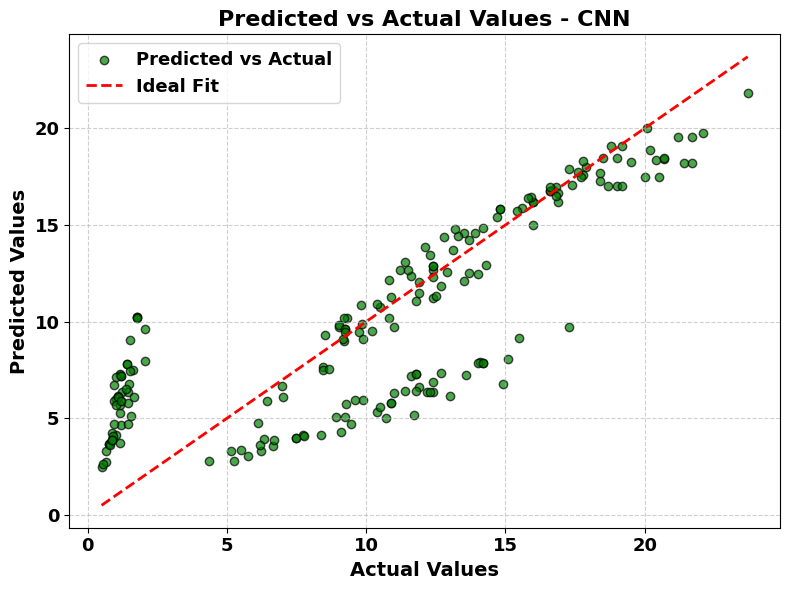

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import keras_tuner as kt
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, explained_variance_score
import matplotlib.pyplot as plt

# 1. Prepare Features and Target
X = df.drop(columns=["Efficiency"])
y = df["Efficiency"]

# 2. Split and Scale - Strictly fit ONLY on Training set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Reshape for CNN input: (samples, features, 1)
X_train_cnn = X_train_scaled.reshape((-1, X_train_scaled.shape[1], 1))
X_test_cnn = X_test_scaled.reshape((-1, X_test_scaled.shape[1], 1))

# 3. Model Building Function for Tuner and CV
def build_model(hp):
    model = keras.Sequential()
    model.add(layers.Input(shape=(X_train_scaled.shape[1], 1)))

    model.add(layers.Conv1D(
        filters=hp.Int('filters1', 32, 128, step=32),
        kernel_size=hp.Choice('kernel_size1', [2, 3]),
        activation='relu'
    ))
    model.add(layers.Conv1D(
        filters=hp.Int('filters2', 32, 128, step=32),
        kernel_size=hp.Choice('kernel_size2', [2, 3]),
        activation='relu'
    ))
    model.add(layers.Flatten())
    model.add(layers.Dense(units=hp.Int('dense_units', 32, 128, step=32), activation='relu'))
    model.add(layers.Dense(1))

    model.compile(
        optimizer=keras.optimizers.Adam(hp.Choice('learning_rate', [1e-2, 1e-3, 1e-4])),
        loss='mse', metrics=['mae']
    )
    return model

# 4. Hyperparameter Tuning
tuner = kt.RandomSearch(build_model, objective='val_loss', max_trials=10, directory='cnn_cv_dir')
early_stop = tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)

tuner.search(X_train_cnn, y_train, validation_split=0.2, epochs=100, callbacks=[early_stop], verbose=0)
best_hps = tuner.get_best_hyperparameters(1)[0]
print(f"--- Best Hyperparameters Found ---")
print(best_hps.values)

# 5. PERFORM 5-FOLD CROSS-VALIDATION (Reviewer Requirement)

print("\n--- Starting 5-Fold Cross-Validation (Training Set) ---")
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Lists to store metrics for each fold
cv_r2, cv_mse, cv_rmse, cv_mae = [], [], [], []

for fold, (train_idx, val_idx) in enumerate(kf.split(X_train_cnn, y_train)):
    # Build fresh model with optimized architecture
    model = build_model(best_hps)

    # Train on the fold split
    model.fit(X_train_cnn[train_idx], y_train.iloc[train_idx],
              epochs=100, batch_size=32, verbose=0, callbacks=[early_stop],
              validation_data=(X_train_cnn[val_idx], y_train.iloc[val_idx]))

    # Predict and Evaluate
    preds = model.predict(X_train_cnn[val_idx]).flatten()
    cv_r2.append(r2_score(y_train.iloc[val_idx], preds))
    cv_mse.append(mean_squared_error(y_train.iloc[val_idx], preds))
    cv_rmse.append(np.sqrt(cv_mse[-1]))
    cv_mae.append(mean_absolute_error(y_train.iloc[val_idx], preds))

    print(f"Fold {fold+1} | R2: {cv_r2[-1]:.4f} | RMSE: {cv_rmse[-1]:.4f}")

print("\n--- Mean Cross-Validation Results ---")
print(f"Mean CV R2: {np.mean(cv_r2):.6f} (+/- {np.std(cv_r2):.6f})")
print(f"Mean CV MSE: {np.mean(cv_mse):.6f}")
print(f"Mean CV RMSE: {np.mean(cv_rmse):.6f}")
print(f"Mean CV MAE: {np.mean(cv_mae):.6f}")

# 6. Final Evaluation on Unseen Test Set
final_model = tuner.get_best_models(num_models=1)[0]
y_test_pred = final_model.predict(X_test_cnn).flatten()

print("\n--- Final Test Metrics (Unseen Data) ---")
mse_test = mean_squared_error(y_test, y_test_pred)
print(f"Mean Squared Error (MSE): {mse_test:.6f}")
print(f"Root Mean Squared Error (RMSE): {np.sqrt(mse_test):.6f}")
print(f"Mean Absolute Error (MAE): {mean_absolute_error(y_test, y_test_pred):.6f}")
print(f"R2 Score: {r2_score(y_test, y_test_pred):.6f}")
print(f"Explained Variance: {explained_variance_score(y_test, y_test_pred):.6f}")

# 7. Parity Plot
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_test_pred, color='green', edgecolor='black',
            alpha=0.7, label='Predicted vs Actual')

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', lw=2, label='Ideal Fit')

plt.title('Predicted vs Actual Values - CNN', fontsize=16, fontweight='bold')
plt.xlabel('Actual Values', fontsize=14, fontweight='bold')
plt.ylabel('Predicted Values', fontsize=14, fontweight='bold')

# Axis numbers bold + larger
plt.xticks(fontsize=13, fontweight='bold')
plt.yticks(fontsize=13, fontweight='bold')

# 🔹 Legend bold
plt.legend(prop={'size': 13, 'weight': 'bold'})

plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

plt.savefig("/content/drive/MyDrive/solar3/Final_CNN_Parity_Plot.png", dpi=300)
plt.show()

# **LSTM Regressor**

--- Best Hyperparameters Found ---
{'lstm_units1': 128, 'lstm_units2': 96, 'dense_units': 96, 'learning_rate': 0.01}

--- Starting 5-Fold Cross-Validation (Training Set) ---
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step
Fold 1 | R2: 0.6439 | RMSE: 3.5839
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 92ms/step
Fold 2 | R2: 0.6752 | RMSE: 3.5022
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 93ms/step
Fold 3 | R2: 0.6727 | RMSE: 3.7785
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step
Fold 4 | R2: 0.6419 | RMSE: 3.9550
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step
Fold 5 | R2: 0.1310 | RMSE: 5.6440

--- Mean Cross-Validation Results ---
Mean CV R2: 0.552948 (+/- 0.211413)
Mean CV MSE: 17.376648
Mean CV RMSE: 4.092712
Mean CV MAE: 3.235892


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step

--- Final Test Metrics (Unseen Data) ---
Mean Squared Error (MSE): 11.976335
Root Mean Squared Error (RMSE): 3.460684
Mean Absolute Error (MAE): 2.591948
R2 Score: 0.698960
Explained Variance: 0.699224


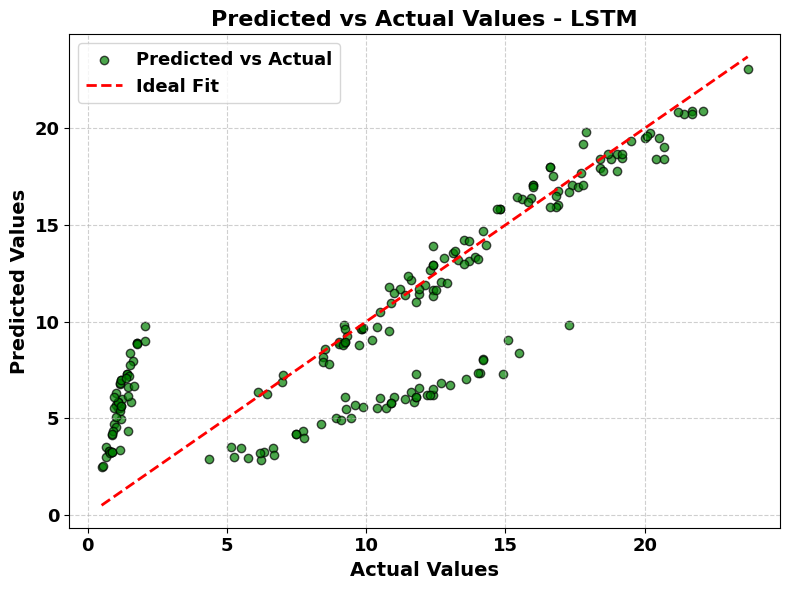

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import keras_tuner as kt
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, explained_variance_score
import matplotlib.pyplot as plt

# 1. Prepare Features and Target
X = df.drop(columns=["Efficiency"])
y = df["Efficiency"]

# 2. Split and Scale - Strictly fit ONLY on Training set to prevent leakage
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Reshape for LSTM input: (samples, time_steps, features)
# Treating the 5 input features as 5 time steps with 1 feature each
X_train_lstm = X_train_scaled.reshape((-1, X_train_scaled.shape[1], 1))
X_test_lstm = X_test_scaled.reshape((-1, X_test_scaled.shape[1], 1))

# 3. Model Building Function for Tuner and CV
def build_model(hp):
    model = keras.Sequential()
    model.add(layers.Input(shape=(X_train_lstm.shape[1], 1)))

    # Tuning two LSTM layers
    model.add(layers.LSTM(
        units=hp.Int('lstm_units1', 32, 128, step=32),
        return_sequences=True
    ))
    model.add(layers.LSTM(
        units=hp.Int('lstm_units2', 32, 128, step=32),
        return_sequences=False
    ))

    # Tuning a dense layer before the output
    model.add(layers.Dense(units=hp.Int('dense_units', 32, 128, step=32), activation='relu'))
    model.add(layers.Dense(1))

    model.compile(
        optimizer=keras.optimizers.Adam(hp.Choice('learning_rate', [1e-2, 1e-3, 1e-4])),
        loss='mse', metrics=['mae']
    )
    return model

# 4. Hyperparameter Tuning
tuner = kt.RandomSearch(build_model, objective='val_loss', max_trials=10, directory='lstm_cv_dir', overwrite=True)
early_stop = tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)

tuner.search(X_train_lstm, y_train, validation_split=0.2, epochs=100, callbacks=[early_stop], verbose=0)
best_hps = tuner.get_best_hyperparameters(1)[0]
print(f"--- Best Hyperparameters Found ---")
print(best_hps.values)

# 5. PERFORM 5-FOLD CROSS-VALIDATION (The Reviewer's Key Requirement)
print("\n--- Starting 5-Fold Cross-Validation (Training Set) ---")
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Lists to store metrics for each fold
cv_r2, cv_mse, cv_rmse, cv_mae = [], [], [], []

for fold, (train_idx, val_idx) in enumerate(kf.split(X_train_lstm, y_train)):
    # Build a fresh model instance with best hyperparameters
    model = build_model(best_hps)

    # Train on the current fold
    model.fit(X_train_lstm[train_idx], y_train.iloc[train_idx],
              epochs=100, batch_size=32, verbose=0, callbacks=[early_stop],
              validation_data=(X_train_lstm[val_idx], y_train.iloc[val_idx]))

    # Predict and evaluate on the validation fold
    preds = model.predict(X_train_lstm[val_idx]).flatten()

    cv_r2.append(r2_score(y_train.iloc[val_idx], preds))
    cv_mse.append(mean_squared_error(y_train.iloc[val_idx], preds))
    cv_rmse.append(np.sqrt(cv_mse[-1]))
    cv_mae.append(mean_absolute_error(y_train.iloc[val_idx], preds))

    print(f"Fold {fold+1} | R2: {cv_r2[-1]:.4f} | RMSE: {cv_rmse[-1]:.4f}")

print("\n--- Mean Cross-Validation Results ---")
print(f"Mean CV R2: {np.mean(cv_r2):.6f} (+/- {np.std(cv_r2):.6f})")
print(f"Mean CV MSE: {np.mean(cv_mse):.6f}")
print(f"Mean CV RMSE: {np.mean(cv_rmse):.6f}")
print(f"Mean CV MAE: {np.mean(cv_mae):.6f}")

# 6. Final Evaluation on Unseen Test Set
final_model = tuner.get_best_models(1)[0]
y_test_pred = final_model.predict(X_test_lstm).flatten()

print("\n--- Final Test Metrics (Unseen Data) ---")
mse_test = mean_squared_error(y_test, y_test_pred)
print(f"Mean Squared Error (MSE): {mse_test:.6f}")
print(f"Root Mean Squared Error (RMSE): {np.sqrt(mse_test):.6f}")
print(f"Mean Absolute Error (MAE): {mean_absolute_error(y_test, y_test_pred):.6f}")
print(f"R2 Score: {r2_score(y_test, y_test_pred):.6f}")
print(f"Explained Variance: {explained_variance_score(y_test, y_test_pred):.6f}")

# 7. Parity Plot for Manuscript
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_test_pred, color='green', edgecolor='black',
            alpha=0.7, label='Predicted vs Actual')

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', lw=2, label='Ideal Fit')

plt.title('Predicted vs Actual Values - LSTM', fontsize=16, fontweight='bold')
plt.xlabel('Actual Values', fontsize=14, fontweight='bold')
plt.ylabel('Predicted Values', fontsize=14, fontweight='bold')

# Axis numbers bold + larger
plt.xticks(fontsize=13, fontweight='bold')
plt.yticks(fontsize=13, fontweight='bold')

# 🔹 Legend bold
plt.legend(prop={'size': 13, 'weight': 'bold'})

plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

plt.savefig("/content/drive/MyDrive/solar3/Final_LSTM_Parity_Plot.png", dpi=300)
plt.show()

# **ANN**

--- Best Hyperparameters Found ---
{'dense_units1': 64, 'dense_units2': 32, 'learning_rate': 0.01}

--- Starting 5-Fold Cross-Validation (Training Set) ---
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
Fold 1 | R2: 0.6635 | RMSE: 3.4837
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
Fold 2 | R2: 0.6704 | RMSE: 3.5281
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
Fold 3 | R2: 0.6841 | RMSE: 3.7120
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
Fold 4 | R2: 0.7363 | RMSE: 3.3938
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
Fold 5 | R2: 0.4687 | RMSE: 4.4130

--- Mean Cross-Validation Results ---
Mean CV R2: 0.644618 (+/- 0.091566)
Mean CV MSE: 13.871061
Mean CV RMSE: 3.706126
Mean CV MAE: 2.904643
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))



--- Final Test Metrics (Unseen Data) ---
Mean Squared Error (MSE): 12.493487
Root Mean Squared Error (RMSE): 3.534613
Mean Absolute Error (MAE): 2.641391
R2 Score: 0.685960
Explained Variance Score: 0.686367


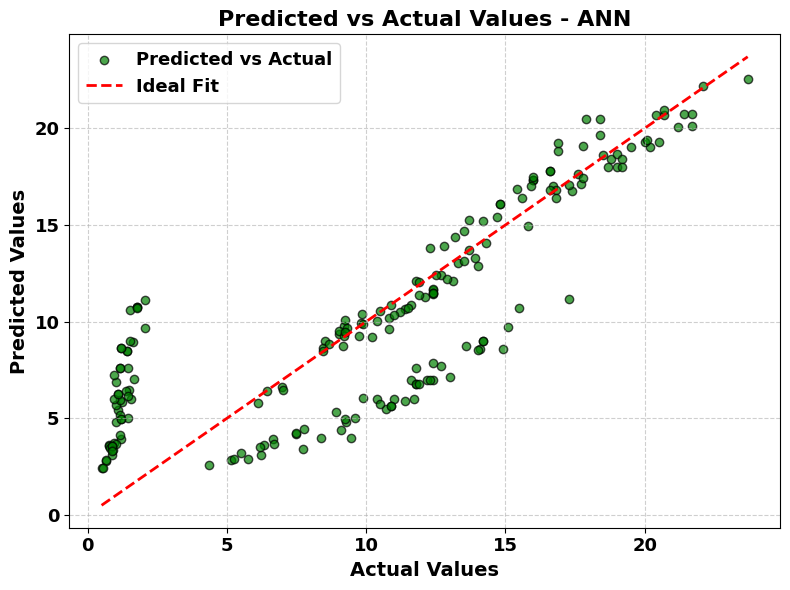

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import keras_tuner as kt
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, explained_variance_score
import matplotlib.pyplot as plt

# 1. Prepare Features and Target
X = df.drop(columns=["Efficiency"])
y = df["Efficiency"]

# 2. Split and Scale - Strictly fit ONLY on Training set to prevent data leakage
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Model Building Function for Tuner and CV
def build_model(hp):
    model = keras.Sequential()
    model.add(layers.Input(shape=(X_train_scaled.shape[1],)))

    # Replicating your architecture with tuning
    model.add(layers.Dense(
        units=hp.Int('dense_units1', 32, 128, step=32),
        activation='relu'
    ))
    model.add(layers.Dense(
        units=hp.Int('dense_units2', 32, 128, step=32),
        activation='relu'
    ))
    model.add(layers.Dense(1))

    model.compile(
        optimizer=keras.optimizers.Adam(hp.Choice('learning_rate', [1e-2, 1e-3, 1e-4])),
        loss='mse', metrics=['mae']
    )
    return model

# 4. Initial Hyperparameter Tuning
tuner = kt.RandomSearch(build_model, objective='val_loss', max_trials=10, directory='ann_cv_dir', overwrite=True)
early_stop = tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)

tuner.search(X_train_scaled, y_train, validation_split=0.2, epochs=100, callbacks=[early_stop], verbose=0)
best_hps = tuner.get_best_hyperparameters(1)[0]
print(f"--- Best Hyperparameters Found ---")
print(best_hps.values)

# 5. PERFORM 5-FOLD CROSS-VALIDATION (The Reviewer's Key Requirement)
print("\n--- Starting 5-Fold Cross-Validation (Training Set) ---")
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Lists to store metrics for each fold
cv_r2, cv_mse, cv_rmse, cv_mae = [], [], [], []

for fold, (train_idx, val_idx) in enumerate(kf.split(X_train_scaled, y_train)):
    # Build fresh model with optimized architecture
    model = build_model(best_hps)

    # Train on the fold split
    model.fit(X_train_scaled[train_idx], y_train.iloc[train_idx],
              epochs=100, batch_size=32, verbose=0, callbacks=[early_stop],
              validation_data=(X_train_scaled[val_idx], y_train.iloc[val_idx]))

    # Predict and evaluate on the validation fold
    preds = model.predict(X_train_scaled[val_idx]).flatten()

    # Calculate metrics
    cv_r2.append(r2_score(y_train.iloc[val_idx], preds))
    cv_mse.append(mean_squared_error(y_train.iloc[val_idx], preds))
    cv_rmse.append(np.sqrt(cv_mse[-1]))
    cv_mae.append(mean_absolute_error(y_train.iloc[val_idx], preds))

    print(f"Fold {fold+1} | R2: {cv_r2[-1]:.4f} | RMSE: {cv_rmse[-1]:.4f}")

print("\n--- Mean Cross-Validation Results ---")
print(f"Mean CV R2: {np.mean(cv_r2):.6f} (+/- {np.std(cv_r2):.6f})")
print(f"Mean CV MSE: {np.mean(cv_mse):.6f}")
print(f"Mean CV RMSE: {np.mean(cv_rmse):.6f}")
print(f"Mean CV MAE: {np.mean(cv_mae):.6f}")

# 6. Final Evaluation on Unseen Test Set
final_model = tuner.get_best_models(num_models=1)[0]
y_test_pred = final_model.predict(X_test_scaled).flatten()

print("\n--- Final Test Metrics (Unseen Data) ---")
mse_test = mean_squared_error(y_test, y_test_pred)
print(f"Mean Squared Error (MSE): {mse_test:.6f}")
print(f"Root Mean Squared Error (RMSE): {np.sqrt(mse_test):.6f}")
print(f"Mean Absolute Error (MAE): {mean_absolute_error(y_test, y_test_pred):.6f}")
print(f"R2 Score: {r2_score(y_test, y_test_pred):.6f}")
print(f"Explained Variance Score: {explained_variance_score(y_test, y_test_pred):.6f}")

# 7. Parity Plot for Manuscript
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_test_pred, color='green', edgecolor='black',
            alpha=0.7, label='Predicted vs Actual')

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', lw=2, label='Ideal Fit')

plt.title('Predicted vs Actual Values - ANN', fontsize=16, fontweight='bold')
plt.xlabel('Actual Values', fontsize=14, fontweight='bold')
plt.ylabel('Predicted Values', fontsize=14, fontweight='bold')

# Axis numbers bold + larger
plt.xticks(fontsize=13, fontweight='bold')
plt.yticks(fontsize=13, fontweight='bold')

# 🔹 Legend bold
plt.legend(prop={'size': 13, 'weight': 'bold'})

plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

plt.savefig("/content/drive/MyDrive/solar3/Final_ANN_Parity_Plot.png", dpi=300)
plt.show()

In [ ]:
pip install keras-tuner


In [ ]:
pip install catboost


In [ ]:
pip install scikeras


In [ ]:
pip install scikeras


# **SHAP**

 99%|===================| 202/205 [00:12<00:00]       

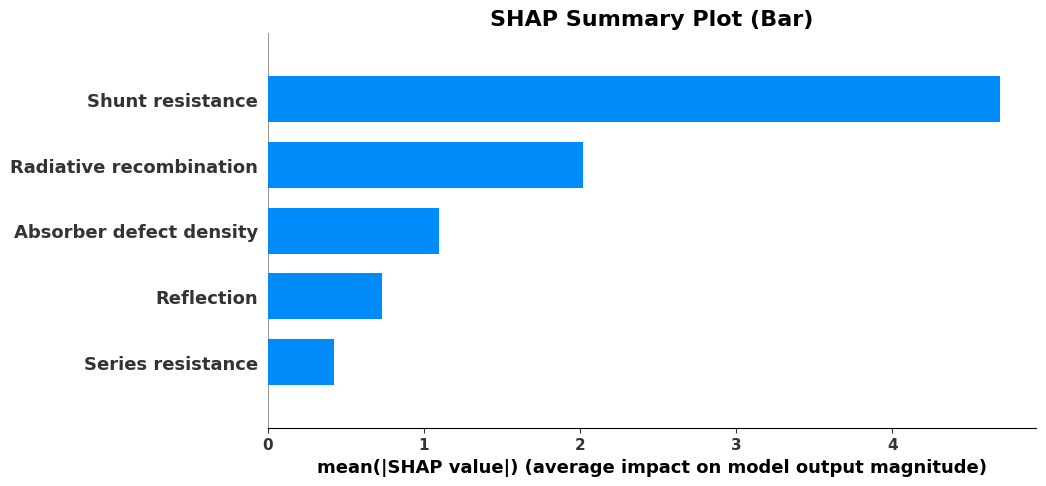

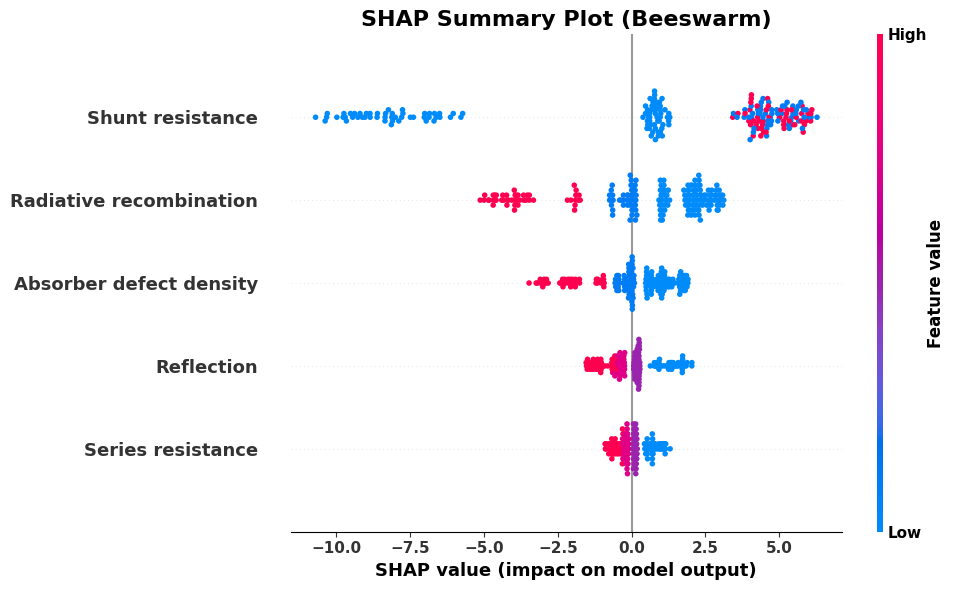

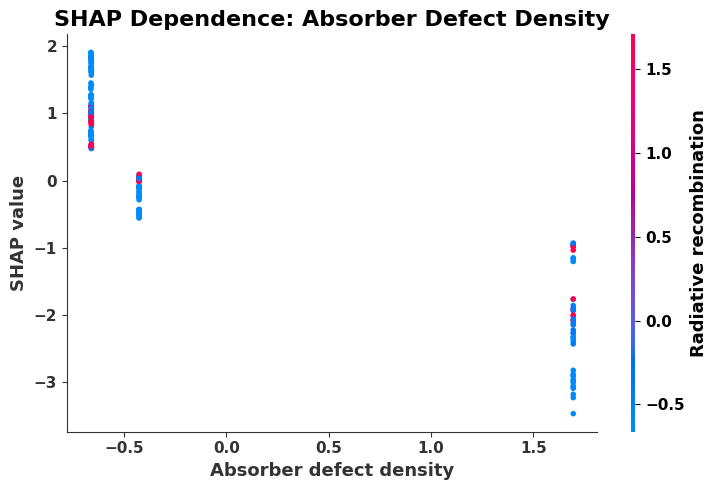

In [ ]:
import shap
import matplotlib.pyplot as plt
import matplotlib
import pandas as pd

# Set all font text to bold globally for matplotlib
matplotlib.rcParams.update({
    'font.weight': 'bold',
    'axes.labelweight': 'bold',
    'axes.titlesize': 16,
    'axes.titleweight': 'bold',
    'xtick.labelsize': 14,
    'ytick.labelsize': 14
})

# 1. Initialize SHAP Explainer
explainer = shap.Explainer(best_model, X_train_scaled_df)

# 2. Compute SHAP values
shap_values = explainer(X_test_scaled_df)

# 3. Summary Bar Plot
shap.summary_plot(shap_values, X_test_scaled_df, plot_type="bar", show=False)
fig = plt.gcf()  # Get current figure
fig.set_size_inches(12, 6)  # Set desired size
plt.title("SHAP Summary Plot (Bar)", fontweight='bold')  # Set title
fig.subplots_adjust(bottom=0.3)  # Ensure x-axis labels are not cut off
fig.savefig("/content/drive/MyDrive/solar3/SHAP_Summary_Bar_XGB1.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

# 4. Summary Beeswarm Plot
shap.summary_plot(shap_values, X_test_scaled_df, plot_type="dot", show=False)
fig = plt.gcf()
plt.title("SHAP Summary Plot (Beeswarm)", fontweight='bold')
fig.set_size_inches(10, 6)
fig.tight_layout()
fig.savefig("/content/drive/MyDrive/solar3/SHAP_Summary_Beeswarm_XGB.png", dpi=300)
plt.show()
plt.close()

# 5. Dependence Plot
shap.dependence_plot(
    "Absorber defect density",
    shap_values.values,
    X_test_scaled_df,
    show=False
)
fig = plt.gcf()
plt.title("SHAP Dependence: Absorber Defect Density", fontweight='bold')
plt.xlabel("Absorber defect density", fontweight='bold')
plt.ylabel("SHAP value", fontweight='bold')
fig.tight_layout()
fig.savefig("/content/drive/MyDrive/solar3/SHAP_Dependence_AbsorberDefect_XGB.png", dpi=300)
plt.show()
plt.close()

# 6. Force Plot (interactive)
shap.initjs()
i = 0
force_plot = shap.force_plot(
    explainer.expected_value,
    shap_values[i].values,
    X_test_scaled_df.iloc[i],
    feature_names=X_test_scaled_df.columns
)
shap.save_html("/content/drive/MyDrive/solar3/SHAP_Force_Instance0_XGB.html", force_plot)


In [ ]:
import pandas as pd

# Define the instances and your actual feature names
selected_instances = list(range(10))  # Instances 0 to 9
selected_features = [
    "Absorber defect density",
    "Series resistance",
    "Shunt resistance",
    "Reflection",
    "Radiative recombination"
]

# Initialize the table
shap_table = pd.DataFrame(columns=["Instance"] + selected_features)

# Extract SHAP values for the selected instances and features
for i in selected_instances:
    row = {"Instance": i}
    for feature in selected_features:
        row[feature] = shap_values[i, X_test_scaled_df.columns.get_loc(feature)].values
    shap_table = pd.concat([shap_table, pd.DataFrame([row])], ignore_index=True)

# Save to Excel
shap_table.to_excel("/content/drive/MyDrive/solar3/SHAP_Table_Your_Features.xlsx", index=False)

# Print the table (optional)
shap_table


/tmp/ipython-input-2939893799.py:21: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  shap_table = pd.concat([shap_table, pd.DataFrame([row])], ignore_index=True)


,Instance,Absorber defect density,Series resistance,Shunt resistance,Reflection,Radiative recombination
0,0,0.023279,0.470347,-7.785430,-0.659462,0.002351
1,1,1.079886,0.170518,4.951557,0.247525,-0.641179
2,2,0.947764,-0.179643,3.968035,-0.949684,-4.398358
3,3,1.267420,0.697450,0.598006,-1.504576,2.253536
4,4,-0.435417,0.149897,5.080489,-0.523290,2.191953
5,5,-0.105378,0.064346,-8.617737,-0.286926,0.998759
6,6,1.630005,-0.255094,5.521773,-1.351374,2.712557
7,7,-0.192669,-0.457300,0.863357,-1.203305,1.768240
8,8,0.507363,0.057519,-6.502555,-0.558577,-1.888653
9,9,-0.099259,-0.328859,-8.349623,-0.263716,0.974437
